# Mini-projeto M2 

## Dataset MNIST (Modified National Institute of Standards and Technology)

O **MNIST** é o dataset "Hello World" da visão computacional, ideal para testar métodos de reconhecimento de padrões com um mínimo esforço de pré-processamento.

### Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

* Importar o dataset MNIST via scikit-learn (fetch_openml('mnist_784')) ou via tensorflow.keras.datasets.mnist.


In [4]:
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")


Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


* Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

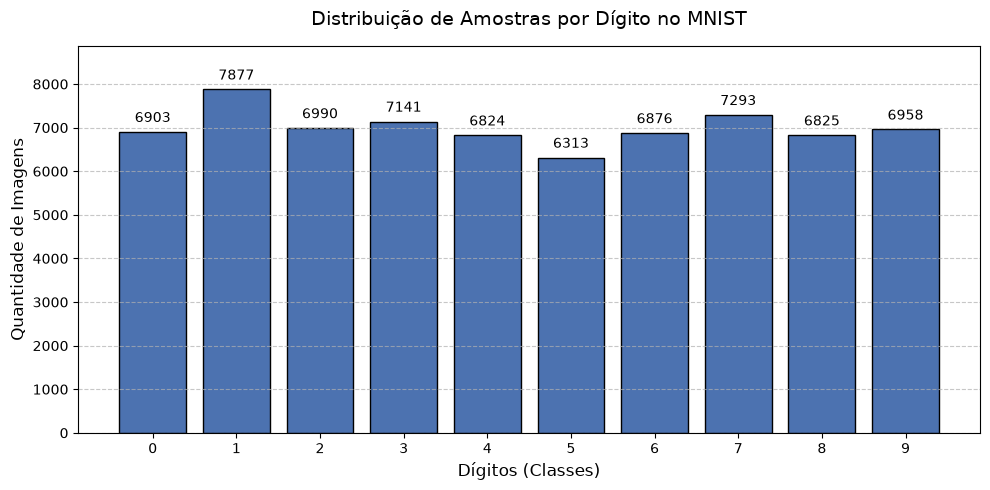

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Descrição completa do dataset
print(mnist.DESCR)
print("Chaves:", mnist.keys())

# Separando as matrizes de features (X) (as imagens) e rótulos/alvo (y) (os rótulos de 0 a 9)
X, y = mnist.data, mnist.target

print("-" * 40)
print("📊 ANÁLISE EXPLORATÓRIA DO MNIST 📊")
print("-" * 40)
print(f"Dimensão de X (Imagens): {X.shape} -> {X.shape[0]} amostras com {X.shape[1]} features cada")
n_pixels = int(np.sqrt(X.shape[1]))
print(f"Formato original de cada feature X: imagem de {n_pixels}x{n_pixels} = {X.shape[1]} pixels")
print(f"Dimensão de y (Rótulos): {y.shape} -> {y.shape[0]} respostas correspondentes")
print(f"Rótulos possíveis: {sorted(set(mnist.target))}")
print("-" * 40)

# -------------------------------------------------------------
# Balanceamento das classes (dígitos de 0 a 9)
classes, contagens = np.unique(y, return_counts=True)
print("\nDistribuição de amostras por dígito:")
for c, count in zip(classes, contagens):
    print(f"Dígito {c}: {count} imagens")

# Vamos fazer um histograma da distribuição
plt.figure(figsize=(10, 5))
barras = plt.bar(classes, contagens, color='#4C72B0', edgecolor='black')

plt.title("Distribuição de Amostras por Dígito no MNIST", fontsize=14, pad=15)
plt.xlabel("Dígitos (Classes)", fontsize=12)
plt.ylabel("Quantidade de Imagens", fontsize=12)
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 150,
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(contagens) + 1000)

plt.tight_layout()
plt.show()


* Gerar uma grade visual  de no mínimo 2 x 5 com matplotlib, exibindo exemplos de imagens de cada dígito junto com seus respectivos rótulos originais.


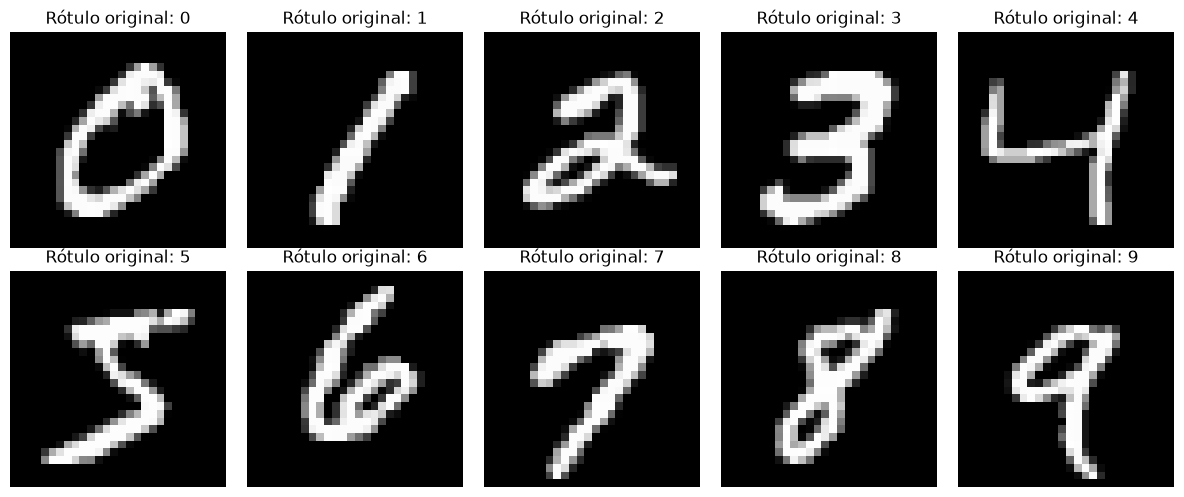

In [6]:
# Extraindo algumas imagens

# Criamos uma grade 2x5 para exibir um exemplo de cada dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    # Garantimos uma imagem de cada número
    idx = np.where(y == str(i))[0][0]

    imagem_28x28 = X[idx].reshape(28, 28)

    axes[i].imshow(imagem_28x28, cmap='gray')
    axes[i].set_title(f"Rótulo original: {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

* Inserir célula de texto interpretando a estrutura dos dados: explicar o significado da escala de intensidade de pixels (0 a 255) e como imagens bidimensionais (28 x 28) são representadas vetorialmente (784 features).

**Estrutura e Origem**

* **Volume Total:** 70.000 imagens de dígitos manuscritos (0 a 9).

* **Autoria:** Criado a partir de bases do NIST americano, misturando amostras escritas por funcionários do censo (base mais limpa) e estudantes do ensino médio (base mais ruidosa).

**Características Técnicas**

* **Formato Original:** Matrizes de $28 \times 28$ pixels. Os dígitos foram normalizados em tamanho e centralizados calculando o "centro de massa" dos pixels.

* **Vetorização:** Para a maioria dos algoritmos, a matriz bidimensional é "achatada" num vetor $\vec{x}$ de **784 dimensões** (features).

* **Intensidade (Pixels):** Escala de cinza de **0** (fundo) a **255** (traço máximo). Os tons de cinza intermediários são resultado da técnica de *anti-aliasing* usada na redução da imagem original.

Então, temos o seguinte problema: cada imagem $i$ é um vetor $\vec{x}^{(i)} = (x_1^{(i)},..., x_{784}^{(i)})$, em que as componentes $x_{j}^{(i)}$ é um pixel com um valor entre $0$ e $255$. Queremos aprender a classificar esses vetores dentros dos rótulos de $0$ a $9$.

**Balanceamento de Classes**

O dataset apresenta uma distribuição muito equilibrada (sem forte viés para nenhum número específico). As amostras variam de forma suave entre o **dígito 5** (classe minoritária, com 6.313 imagens) e o **dígito 1** (classe majoritária, com 7.877 imagens), com a média girando em torno de 7.000 imagens por número.

### Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

* Divisão Estratificada: Dividir a base em Treino, Validação e Teste (ex: 70% treino, 10% validação e 20% teste ou 80% treino/validação e 20% teste), garantindo estratificação por classe (stratify=y).


📊 DIVISÃO ESTRATIFICADA DOS DADOS 📊
--------------------------------------------------
Conjunto de Treino:    49000 amostras (70%)
Conjunto de Validação: 7000  amostras (10%)
Conjunto de Teste:     14000 amostras (20%)
--------------------------------------------------


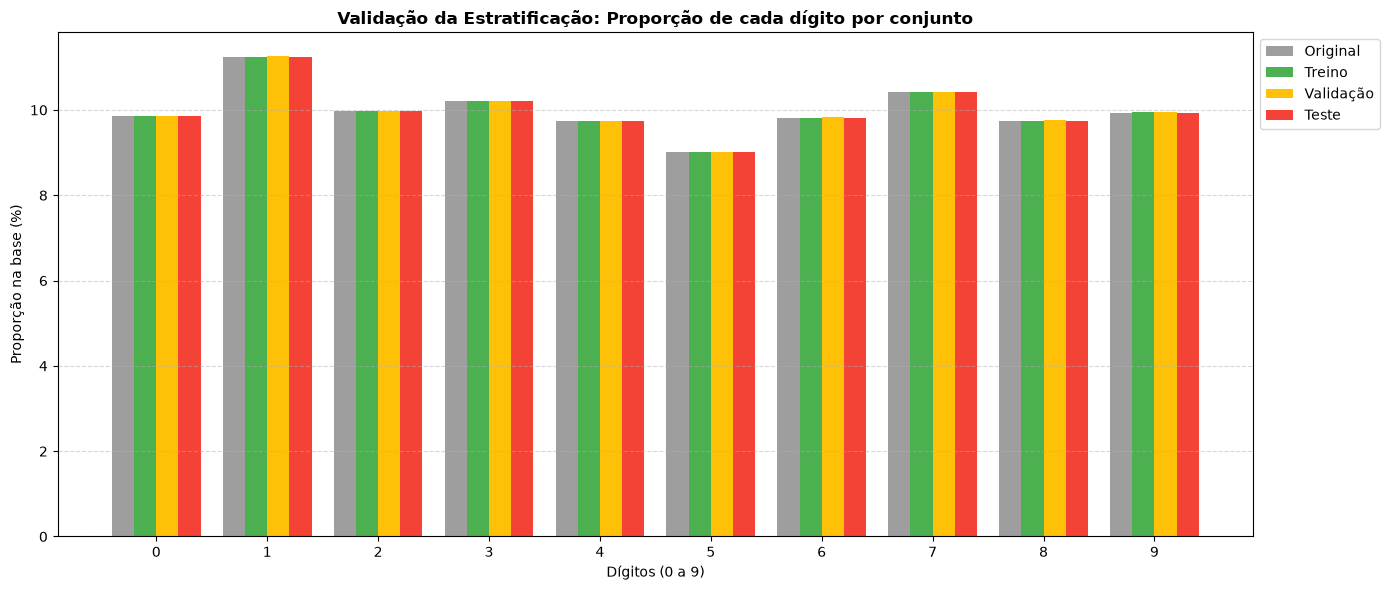

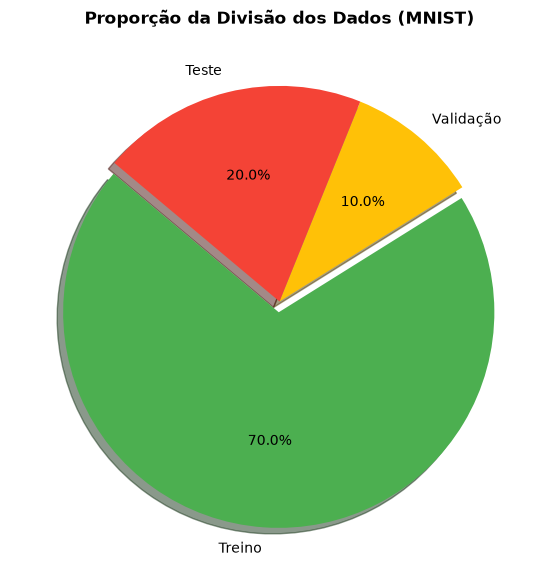

In [7]:
from sklearn.model_selection import train_test_split

# Primeiro vamos separar Teste (20%) e o restante temporário para Treino/Validação (80%)
# Os dados de teste só serão acessados ao final, garantindo que o modelo não teve acesso durante o treino.
# Usamos o stratify para garantir a mesma proporção de classes. Do contrário, por exemplo, poderíamos ter muitos 8 e nenhum 2.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20, # proporção do split 20%
    stratify=y,     # mesma proporção de classes  
    random_state=42 # random padrão para a reprodutibilidade
)

# Separar Validação (10% do total) e Treino (70% do total) a partir do temp
# 12.5% de 80% = 10% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    stratify=y_temp,  # Mantemos a estratificação
    random_state=42
)

print("📊 DIVISÃO ESTRATIFICADA DOS DADOS 📊")
print("-" * 50)
print(f"Conjunto de Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de Validação: {X_val.shape[0]}  amostras ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")
print("-" * 50)

# ----------------------------------------------------
# Vamos comprovar a eficácia da estratificação (stratify=y)

def check_proportion(y_array):
    _, counts = np.unique(y_array, return_counts=True)
    return (counts / len(y_array)) * 100

# Extraindo as porcentagens para cada conjunto
prop_orig = check_proportion(y)
prop_train = check_proportion(y_train)
prop_val = check_proportion(y_val)
prop_test = check_proportion(y_test)

# Configurações do gráfico
digitos = np.arange(10)
largura = 0.2  # Largura individual de cada barra

plt.figure(figsize=(14, 6))

plt.bar(digitos - largura*1.5, prop_orig, width=largura, label='Original', color='#9E9E9E')
plt.bar(digitos - largura*0.5, prop_train, width=largura, label='Treino', color='#4CAF50')
plt.bar(digitos + largura*0.5, prop_val, width=largura, label='Validação', color='#FFC107')
plt.bar(digitos + largura*1.5, prop_test, width=largura, label='Teste', color='#F44336')

plt.title("Validação da Estratificação: Proporção de cada dígito por conjunto", fontweight='bold')
plt.xlabel("Dígitos (0 a 9)")
plt.ylabel("Proporção na base (%)")
plt.xticks(digitos) # Garante que o eixo X mostre exatamente de 0 a 9
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ----------------------------------------------------
#Vamos fazer um diagrama de pizza

tamanhos = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels = ['Treino', 'Validação', 'Teste']
cores = ['#4CAF50', '#FFC107', '#F44336']
destaque = (0.05, 0, 0)  # Afasta levemente a primeira fatia (Treino) para destaque

plt.figure(figsize=(7, 7))
plt.pie(
    tamanhos, 
    labels=labels, 
    colors=cores, 
    autopct='%1.1f%%', 
    explode=destaque,
    startangle=140,
    shadow=True
)

plt.title("Proporção da Divisão dos Dados (MNIST)", fontweight='bold')
plt.show()

* Normalização / Escalonamento: Aplicar o redimensionamento dos pixels para a escala [0.0, 1.0] (dividindo por 255.0 ou via MinMaxScaler/StandardScaler).
  
* Justificar textualmente a importância da normalização para a convergência de modelos lineares e distâncias métricas.

In [8]:
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

print("📊 VERIFICAÇÃO DO ESCALONAMENTO 📊")
print("-" * 50)
print(f"Treino original:    min {np.min(X_train):.1f} | max {np.max(X_train):.1f}")
print(f"Treino normalizado: min {np.min(X_train_norm):.1f} | max {np.max(X_train_norm):.1f}")
print(f"Teste original:     min {np.min(X_test):.1f} | max {np.max(X_test):.1f}")
print(f"Teste normalizado:  min {np.min(X_test_norm):.1f} | max {np.max(X_test_norm):.1f}")
print("-" * 50)

📊 VERIFICAÇÃO DO ESCALONAMENTO 📊
--------------------------------------------------
Treino original:    min 0.0 | max 255.0
Treino normalizado: min 0.0 | max 1.0
Teste original:     min 0.0 | max 255.0
Teste normalizado:  min 0.0 | max 1.0
--------------------------------------------------


**A Importância Matemática da Normalização [0, 1]**

* **Convergência em Otimizações por Gradiente:** Algoritmos que otimizam pesos minimizando uma função de custo (como regressões logísticas ou redes neurais) dependem da geometria do espaço paramétrico. Quando as *features* possuem escalas muito amplas (0 a 255), as curvas de nível da função de perda tornam-se distorcidas e elípticas, forçando a descida do gradiente a oscilar em "zigue-zague" e atrasando a convergência. Ao redimensionar para [0, 1], a topologia do erro torna-se mais esférica, permitindo que as atualizações dos tensores apontem mais diretamente para o mínimo.
 
* **Estabilidade em Algoritmos Métricos:** Modelos que dependem de similaridade espacial (como KNN ou SVM) calculam rotineiramente a Distância Euclidiana ou de Manhattan. Sem o escalonamento, pixels com valores absolutos naturalmente mais altos dominariam o cálculo da distância hiperespacial de forma desproporcional. A normalização garante que cada dimensão do vetor (pixel) exerça peso equitativo na métrica.

### Fase 3: Implementação e Treinamento dos 3 Modelos

---

Vamos escolher 3 modelos de classificação para tentar prever o número correto presente na imagem. Devemos escolher um modelo de classificação pois cada número representa uma classe dentro do grupo das imagens, não sendo um target contínuo, mas sim, discreto. 

**Metodologia:**
- Para cada modelo vamos variar 2 hiperparâmetros para encontrar a melhor versão de cada modelo
- A escolha da melhor versão será feita avaliando 4 métricas calculadas com o df de validação e maximizando a acurácia do resultado

---

#### SVM (Support Vector Machine)

🔹 Hiperparâmetros que serão testados
- **`C`** (margem de separação):  o quanto estamos penalizando o erro na classificação dos pontos
    - Baixo (0.01–0.1): margem larga, mais tolerância a erros → pode subajustar.
    - Médio (1–10): equilíbrio entre generalização e ajuste.
    - Alto (100–1000): margem estreita, menos tolerância → risco de overfitting.

- **`kernel`**: define a forma da fronteira de decisão (pode ser uma linha reta, um círculo, ...).
    - RBF (Radial Basis Function): padrão, captura fronteiras não lineares; exige ajuste de gamma.
    - Linear: rápido, bom para dados com muitas features e separação linear.

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [7]:

resultados_svm = []

# Inicialização métricas
acc_best = 0.0
best_model_svm = None
best_model_metrics_svm = None
    
for c in np.logspace(-1, 2, num=4, base=10):
    for kernel in ['rbf', 'linear']:
        print(f'C = {c}')
        print(f'kernel = {kernel}')

        modelo_svm = SVC(kernel=kernel, C=c, gamma='scale', decision_function_shape='ovr')
        modelo_svm.fit(X_train_norm, y_train)

        # Faz previsões
        y_pred = modelo_svm.predict(X_val_norm)
        
        # Calcula métricas
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro')
        rec = recall_score(y_val, y_pred, average='macro')
        f1 = f1_score(y_val, y_pred, average='macro')
        
        resultados_svm.append({
            "C": c,
            "Kernel": kernel,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

        if (acc > acc_best):
            best_model_svm = modelo_svm
            acc_best = acc
            best_model_metrics_svm = {
                "C": c,
                "Kernel": kernel,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1
            }



C = 0.1
kernel = rbf
C = 0.1
kernel = linear
C = 1.0
kernel = rbf
C = 1.0
kernel = linear
C = 10.0
kernel = rbf
C = 10.0
kernel = linear
C = 100.0
kernel = rbf
C = 100.0
kernel = linear


In [8]:
# Exibir resultados em formato de tabela
import pandas as pd
df_resultados = pd.DataFrame(resultados_svm)
print(df_resultados)

       C  Kernel  Accuracy  Precision    Recall        F1
0    0.1     rbf  0.953714   0.953600  0.953468  0.953417
1    0.1  linear  0.943000   0.942713  0.942337  0.942433
2    1.0     rbf  0.975571   0.975607  0.975508  0.975543
3    1.0  linear  0.936714   0.936618  0.935872  0.936053
4   10.0     rbf  0.981429   0.981382  0.981328  0.981343
5   10.0  linear  0.927143   0.927169  0.926228  0.926424
6  100.0     rbf  0.981429   0.981355  0.981341  0.981337
7  100.0  linear  0.922143   0.922147  0.921165  0.921304


In [9]:
print(f'''O melhor modelo foi obtido com os hiperparâmetros C = {best_model_metrics_svm['C']} e kernel = {best_model_metrics_svm['Kernel']} \n
As métricas são: 
- Acurácia: {best_model_metrics_svm['Accuracy']}
- Precisão: {best_model_metrics_svm['Precision']}
- Recall: {best_model_metrics_svm['Recall']}
- F1: {best_model_metrics_svm['F1']}''')

O melhor modelo foi obtido com os hiperparâmetros C = 10.0 e kernel = rbf 

As métricas são: 
- Acurácia: 0.9814285714285714
- Precisão: 0.9813824571905956
- Recall: 0.9813278197708583
- F1: 0.981342592613685


Vamos salvar o modelo  para usá-lo na próxima fase aplicando-o no dataset de teste

In [10]:
import joblib

# salvar
joblib.dump(best_model_svm, "models/best_model_svm.pkl")

['models/best_model_svm.pkl']

---

#### Random Forest 

🔹 Hiperparâmetros que serão testados
- **`n_estimators`** (número de árvores)
  - Teste valores como `[50, 100, 200, 500]`.
  - Mais árvores reduzem variância, mas aumentam tempo de treino.

- **`max_depth`** (profundidade máxima das árvores)
  - Teste `[None, 5, 10, 20]`.
  - `None` deixa crescer até o fim → risco de overfitting.
  - Valores menores forçam generalização.



In [28]:
from sklearn.ensemble import RandomForestClassifier

In [51]:

resultados_rf = []


# Inicialização métricas
acc_best = 0.0
best_model_rf = None
best_model_metrics_rf = None
    
for n_estimator in 50 * np.logspace(0, 3, num=4, base=2):
    for max_depth in 5 * np.logspace(0, 2, num=3, base=2):
        print(f'n_estimator = {n_estimator}')
        print(f'max_depth = {max_depth}')

        modelo_rf = RandomForestClassifier(n_estimators=int(n_estimator), max_depth= int(max_depth), random_state=42, n_jobs=-1 ) 
        modelo_rf.fit(X_train_norm, y_train)

        # Faz previsões
        y_pred = modelo_rf.predict(X_val_norm)
        
        # Calcula métricas
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro')
        rec = recall_score(y_val, y_pred, average='macro')
        f1 = f1_score(y_val, y_pred, average='macro')
        
        resultados_rf.append({
            "n_estimator": n_estimator,
            "max_depth": max_depth,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

        if (acc > acc_best):
            best_model_rf = modelo_rf
            acc_best = acc
            best_model_metrics_rf = {
                "n_estimator": n_estimator,
                "max_depth": max_depth,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1
            }




n_estimator = 50.0
max_depth = 5.0
n_estimator = 50.0
max_depth = 10.0
n_estimator = 50.0
max_depth = 20.0
n_estimator = 100.0
max_depth = 5.0
n_estimator = 100.0
max_depth = 10.0
n_estimator = 100.0
max_depth = 20.0
n_estimator = 200.0
max_depth = 5.0
n_estimator = 200.0
max_depth = 10.0
n_estimator = 200.0
max_depth = 20.0
n_estimator = 400.0
max_depth = 5.0
n_estimator = 400.0
max_depth = 10.0
n_estimator = 400.0
max_depth = 20.0


In [52]:
# Exibir resultados em formato de tabela
df_resultados_rf = pd.DataFrame(resultados_rf)
print(df_resultados_rf)

    n_estimator  max_depth  Accuracy  Precision    Recall        F1
0          50.0        5.0  0.849429   0.854888  0.845287  0.845464
1          50.0       10.0  0.944571   0.944878  0.943957  0.944242
2          50.0       20.0  0.962429   0.962283  0.962084  0.962133
3         100.0        5.0  0.854429   0.860358  0.850431  0.850680
4         100.0       10.0  0.946429   0.946681  0.945881  0.946102
5         100.0       20.0  0.965143   0.965053  0.964827  0.964899
6         200.0        5.0  0.859429   0.865850  0.855462  0.855819
7         200.0       10.0  0.947000   0.947234  0.946496  0.946699
8         200.0       20.0  0.966714   0.966649  0.966468  0.966515
9         400.0        5.0  0.858857   0.865632  0.854987  0.855547
10        400.0       10.0  0.947000   0.947192  0.946453  0.946674
11        400.0       20.0  0.966286   0.966175  0.966031  0.966057


In [53]:
print(f'''O melhor modelo foi obtido com os hiperparâmetros n_estimator = {best_model_metrics_rf['n_estimator']} e max_depth = {best_model_metrics_rf['max_depth']} \n
As métricas são: 
- Acurácia: {best_model_metrics_rf['Accuracy']}
- Precisão: {best_model_metrics_rf['Precision']}
- Recall: {best_model_metrics_rf['Recall']}
- F1: {best_model_metrics_rf['F1']}''')

O melhor modelo foi obtido com os hiperparâmetros n_estimator = 200.0 e max_depth = 20.0 

As métricas são: 
- Acurácia: 0.9667142857142857
- Precisão: 0.966648757148436
- Recall: 0.9664682036285136
- F1: 0.9665145989591938


Vamos salvar o modelo  para usá-lo na próxima fase aplicando-o no dataset de teste

In [54]:
# salvar
joblib.dump(best_model_rf, "models/best_model_rf.pkl")

['models/best_model_rf.pkl']

---
#### Neural Network

🔹 Hiperparâmetros importantes
- **`hidden_layer_sizes`**  
  - Define o número de neurônios em cada camada oculta.  
  - Exemplo: `(100,)` → uma camada com 100 neurônios.  
  - `(100, 50)` → duas camadas, a primeira com 100 e a segunda com 50 neurônios.  
  - Teste `[ (50,), (100,), (100,50), (200,) ]`.

- **`activation`**  
  - Função de ativação das camadas ocultas.  
  - Opções: `"relu"` (mais comum),  `"tanh"`, `"logistic"`.  
  - Teste: `"relu"` e `"tanh"`.


In [10]:
from sklearn.neural_network import MLPClassifier 

In [ ]:
resultados_nn = []

# Inicialização métricas
acc_best = 0.0
best_model_nn = None
best_model_metrics_nn = None

# É bom usar potencias de 2 pois são mais próximos do hardware
for layers in [(64, ), (128, ), (16,), (128, 64), (16, 128), (16, 64)]:
    for activation in ["relu", "tanh"]:
        print(f'layers = {layers}')
        print(f'activation = {activation}')

        modelo_nn = MLPClassifier(hidden_layer_sizes=layers, activation= activation ) 
        modelo_nn.fit(X_train_norm_sample, y_train_sample)

        

        # Faz previsões
        y_pred = modelo_nn.predict(X_val_norm)
        
        # Calcula métricas
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro')
        rec = recall_score(y_val, y_pred, average='macro')
        f1 = f1_score(y_val, y_pred, average='macro')
        
        resultados_nn.append({
            "hidden_layer_sizes": layers,
            "activation": activation,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

        if (acc > acc_best):
            best_model_nn = modelo_nn
            acc_best = acc
            


layers = (64,)
activation = relu
layers = (64,)
activation = tanh
layers = (128,)
activation = relu
layers = (128,)
activation = tanh
layers = (16,)
activation = relu


c:\Users\chery\Documents\SCTEC\mini-projeto2\sctec-mini-projeto2\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


layers = (16,)
activation = tanh


c:\Users\chery\Documents\SCTEC\mini-projeto2\sctec-mini-projeto2\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


layers = (128, 64)
activation = relu
layers = (128, 64)
activation = tanh
layers = (16, 128)
activation = relu
layers = (16, 128)
activation = tanh
layers = (16, 64)
activation = relu
layers = (16, 64)
activation = tanh


In [13]:
import pandas as pd

In [56]:
# Exibir resultados em formato de tabela
df_resultados_nn = pd.DataFrame(resultados_nn)
print(df_resultados_nn)

   hidden_layer_sizes activation  Accuracy  Precision    Recall        F1
0               (64,)       relu  0.935714   0.935403  0.935113  0.935108
1               (64,)       tanh  0.928714   0.928434  0.927990  0.927971
2              (128,)       relu  0.937571   0.937340  0.937229  0.937167
3              (128,)       tanh  0.933429   0.933092  0.932786  0.932768
4               (16,)       relu  0.905857   0.905497  0.905103  0.904943
5               (16,)       tanh  0.901571   0.900947  0.900678  0.900474
6           (128, 64)       relu  0.942143   0.941861  0.941784  0.941716
7           (128, 64)       tanh  0.935000   0.934820  0.934408  0.934367
8           (16, 128)       relu  0.919429   0.919045  0.918845  0.918705
9           (16, 128)       tanh  0.912429   0.911697  0.911390  0.911246
10           (16, 64)       relu  0.915000   0.914521  0.914311  0.914247
11           (16, 64)       tanh  0.912714   0.911796  0.911611  0.911521


In [57]:
print(f'''O melhor modelo foi obtido com os hiperparâmetros hidden_layer_sizes = {best_model_metrics_nn['hidden_layer_sizes']} e activation = {best_model_metrics_nn['activation']} \n
As métricas são: 
- Acurácia: {best_model_metrics_nn['Accuracy']}
- Precisão: {best_model_metrics_nn['Precision']}
- Recall: {best_model_metrics_nn['Recall']}
- F1: {best_model_metrics_nn['F1']}''')

O melhor modelo foi obtido com os hiperparâmetros hidden_layer_sizes = (128, 64) e activation = relu 

As métricas são: 
- Acurácia: 0.9421428571428572
- Precisão: 0.9418605847109047
- Recall: 0.9417842328310073
- F1: 0.9417157445757727


Vamos salvar o modelo  para usá-lo na próxima fase aplicando-o no dataset de teste

In [58]:
# salvar
joblib.dump(best_model_nn, "models/best_model_nn.pkl")

['models/best_model_nn.pkl']

### Fase 4: Avaliação Comparativa de Desempenho 

Primeiramente vamos aplicar a melhor versão de cada modelo no dataset de teste

In [2]:
from joblib import load

best_model_svm = load("models/best_model_svm.pkl") 
best_model_rf = load("models/best_model_rf.pkl") 
best_model_nn = load("models/best_model_nn.pkl") 

In [9]:
y_pred_test_svm = best_model_svm.predict(X_test_norm)
y_pred_test_rf  = best_model_rf.predict(X_test_norm)
y_pred_test_nn  = best_model_nn.predict(X_test_norm)

In [26]:
# Vamos definir uma função para calcular a matriz de confusão

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.patches as patches

def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    # Cria o gráfico com seaborn
    plt.figure(figsize=(6,4))

    labels = [f"$\\bf{{{i}}}$" for i in range(10)]  # gera 0–9 em negrito
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)

    # adiciona um retângulo em volta do heatmap
    ax.add_patch(patches.Rectangle((0,0), cm.shape[0], cm.shape[1],
                                fill=False, edgecolor='black', lw=3))

    plt.title("Matriz de Confusão")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

**SVM**

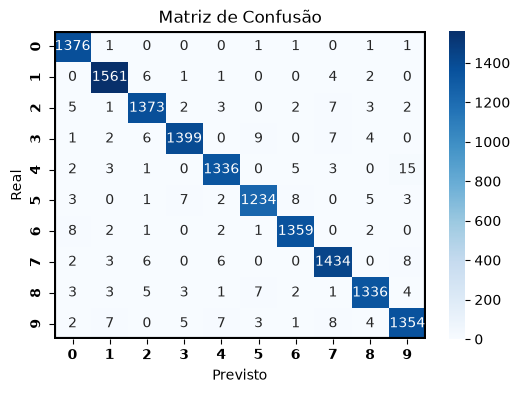

In [ ]:
plot_confusion_matrix(y_test, y_pred_test_svm)

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test_svm, digits=3))

              precision    recall  f1-score   support

           0      0.981     0.996     0.989      1381
           1      0.986     0.991     0.989      1575
           2      0.981     0.982     0.982      1398
           3      0.987     0.980     0.983      1428
           4      0.984     0.979     0.981      1365
           5      0.983     0.977     0.980      1263
           6      0.986     0.988     0.987      1375
           7      0.980     0.983     0.981      1459
           8      0.985     0.979     0.982      1365
           9      0.976     0.973     0.975      1391

    accuracy                          0.983     14000
   macro avg      0.983     0.983     0.983     14000
weighted avg      0.983     0.983     0.983     14000



**Random Forest**

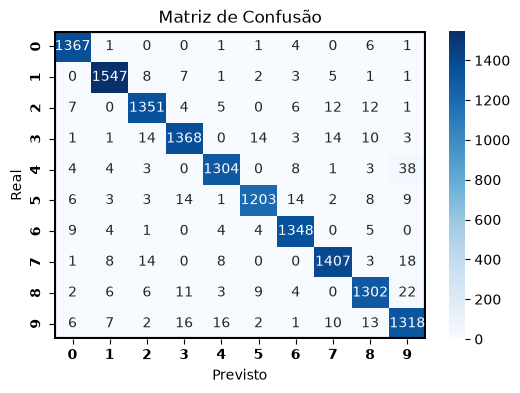

In [28]:
plot_confusion_matrix(y_test, y_pred_test_rf)

In [30]:
print(classification_report(y_test, y_pred_test_rf, digits=3))

              precision    recall  f1-score   support

           0      0.974     0.990     0.982      1381
           1      0.978     0.982     0.980      1575
           2      0.964     0.966     0.965      1398
           3      0.963     0.958     0.961      1428
           4      0.971     0.955     0.963      1365
           5      0.974     0.952     0.963      1263
           6      0.969     0.980     0.975      1375
           7      0.970     0.964     0.967      1459
           8      0.955     0.954     0.955      1365
           9      0.934     0.948     0.941      1391

    accuracy                          0.965     14000
   macro avg      0.965     0.965     0.965     14000
weighted avg      0.965     0.965     0.965     14000



**Neural Network**

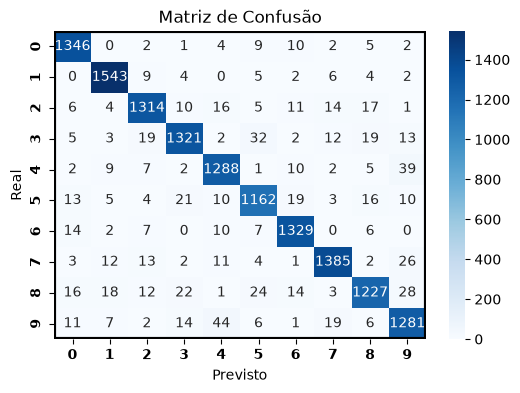

In [31]:
plot_confusion_matrix(y_test, y_pred_test_nn)

In [32]:
print(classification_report(y_test, y_pred_test_nn, digits=3))

              precision    recall  f1-score   support

           0      0.951     0.975     0.962      1381
           1      0.963     0.980     0.971      1575
           2      0.946     0.940     0.943      1398
           3      0.946     0.925     0.935      1428
           4      0.929     0.944     0.936      1365
           5      0.926     0.920     0.923      1263
           6      0.950     0.967     0.958      1375
           7      0.958     0.949     0.954      1459
           8      0.939     0.899     0.918      1365
           9      0.914     0.921     0.917      1391

    accuracy                          0.943     14000
   macro avg      0.942     0.942     0.942     14000
weighted avg      0.943     0.943     0.942     14000

